In [15]:
import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import display, HTML
display(HTML('<style>.container {width: 90% !important; }</style>'))

import glob, pyBigWig, shutil, os
import pandas as pd

import sys
sys.path.append('crestgv/')
from crestgv import crestgv

import seaborn as sns
import matplotlib.pyplot as plt

## Calculate "real" enrichment scores for BCELL genetics, super-PBMC

In [2]:
genetic  = "genetics_test/Bcell_GO_0035456.tsv"
cgv      = crestgv(genetic=genetic, output="pvalues_test/Bcell_GO_0035456/", min_number_genetics=100, collection_name="super_pbmc")
df_cgv   = cgv.calculate_enrichment_score(lessNG=False, greater25k=False)

Removing NaN rows from loaded file ...
Total number of used variants in CREST-GV: 527
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|██████████| 19/19 [00:03<00:00,  5.18it/s]


Intersecting genetic with peak regions ...


100%|██████████| 19/19 [00:09<00:00,  1.94it/s]


For each fold, parallelised shuffling background ...
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


...

Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:16<00:00,  3.37s/it]


Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:16<00:00,  3.26s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.


## Functions to calculate "null" enrichment scores and p-values

In [16]:
def run_null_cgv(genetic, output, random_collection="", random_collection_path=""):
    # Run CREST-GV to get the enrichment scores
    cgv_null = crestgv(genetic=genetic, output=output, 
                       min_number_genetics=100,
                       collection_name=random_collection, in_house_collection_path=random_collection_path) 
    df_cgv_null = cgv_null.calculate_enrichment_score(lessNG=False, greater25k=False) 
    return 

def run_bootstrap(output, N_BOOTS, SEED): 
    # Read the intermediate scores to generate the null distribution
    rounds_null = sorted(glob.glob(output + "/rounds/statistics_intermediate_round*")) 
    dfs_null = []
    for r in rounds_null:
        df = pd.read_csv(r, sep='\t', index_col=0)
        df = df[['CREST-GV']]
        dfs_null.append(df)
        
    df_null = pd.concat(dfs_null)

    # Sample with replacement 10,000 times from df_null to generate a full null
    df_null_bootstrap = df_null.sample(n=N_BOOTS, replace=True, random_state=SEED)

    # Display the two plots of raw null and bootstrap null side by side
    # Add titles to each sub-plot
    fig, (ax1, ax2) = plt.subplots(1,2)
    sns.histplot(df_null['CREST-GV'], kde=False, ax=ax1)
    ax1.set_title("raw_null")
    sns.histplot(df_null_bootstrap['CREST-GV'], kde=True, ax=ax2)
    ax2.set_title("bootstrapped_null")
    fig.show()

    return df_null_bootstrap

def generate_pvalue(genetic, output, real_df_cgv, random_collection="", random_collection_path="", N_BOOTS=10000, SEED=42):
    # Get the null enrichment scores
    run_null_cgv(genetic = genetic, output = output, 
                 random_collection=random_collection, random_collection_path=random_collection_path)
    # Get the null bootstrap distribution (this will plot a figure as it runs)
    df_null_bootstrap = run_bootstrap(output = output, N_BOOTS=N_BOOTS, SEED=SEED)

    # for each real enrichment score count the number of times a value equal to or greater than the observed value was sampled in the bootstrap null and divide by the number of samples
    df_cgv_with_pvals = real_df_cgv
    df_cgv_with_pvals['empirical_pvalue'] = real_df_cgv['CREST-GV_all'].apply(lambda x: (df_null_bootstrap['CREST-GV'] >= x).sum()/N_BOOTS)

    return df_cgv_with_pvals

def plot_pvalue(df_cgv_with_pvals):
    # Arrange by the enrichment score
    df_cgv_with_pvals = df_cgv_with_pvals.sort_values('CREST-GV_all',
                                                     ascending = False)
    
    # Plot the enrichment score and p-value side-by-side
    fig, (ax1, ax2) = plt.subplots(1,2)
    sns.heatmap(df_cgv_with_pvals[['CREST-GV_all']], annot=True, ax=ax1, 
                fmt='.2f', cmap='rocket_r', vmin=0)
    ax1.set_title("enrichment_score")
    sns.heatmap(df_cgv_with_pvals[['empirical_pvalue']], annot=True, ax=ax2, 
                fmt='.2f', cmap='Blues_r', vmin=0, vmax=1)
    ax2.set_title("empirical_pvalue")
    ax2.set_yticklabels([])
    fig.show()
    
    return

## First try this on a small but related collection with few celltypes - immune-cell

Removing NaN rows from loaded file ...
Total number of used variants in CREST-GV: 527
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|██████████| 15/15 [00:01<00:00, 12.75it/s]


Intersecting genetic with peak regions ...


100%|██████████| 15/15 [00:03<00:00,  4.39it/s]

For each fold, parallelised shuffling background ...


...

Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:14<00:00,  2.93s/it]


Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:15<00:00,  3.01s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.


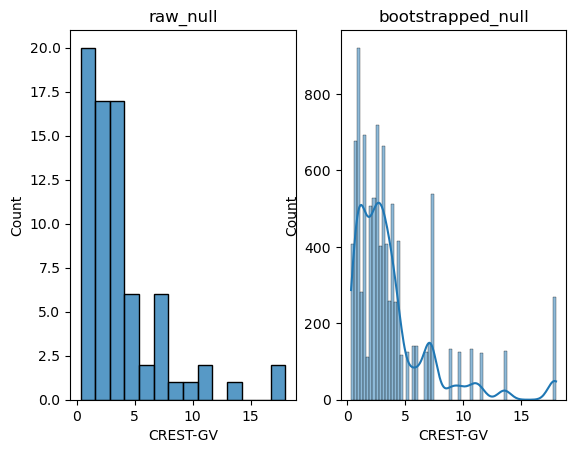

In [87]:
random_collection = "immune_cell"
output = "pvalues_test/Bcell_GO_0035456_" + random_collection + "/"

df_cgv_with_pvals = generate_pvalue(genetic = genetic, output = output, real_df_cgv = df_cgv,
                                    random_collection = random_collection, random_collection_path="")

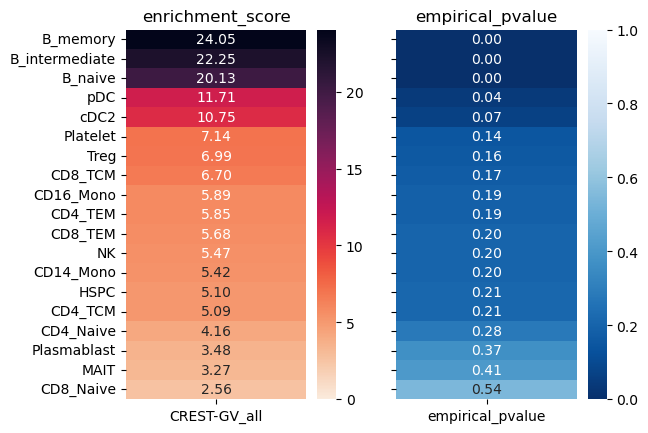

In [88]:
plot_pvalue(df_cgv_pvals)

## Now try on a much larger but unrelated collection to see how the p-values change - catlas-adult

Removing NaN rows from loaded file ...
Total number of used variants in CREST-GV: 527
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|██████████| 111/111 [00:07<00:00, 15.09it/s]


Intersecting genetic with peak regions ...


100%|██████████| 111/111 [00:35<00:00,  3.16it/s]


For each fold, parallelised shuffling background ...
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


...

Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [02:04<00:00, 24.84s/it]


Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [01:59<00:00, 23.84s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.


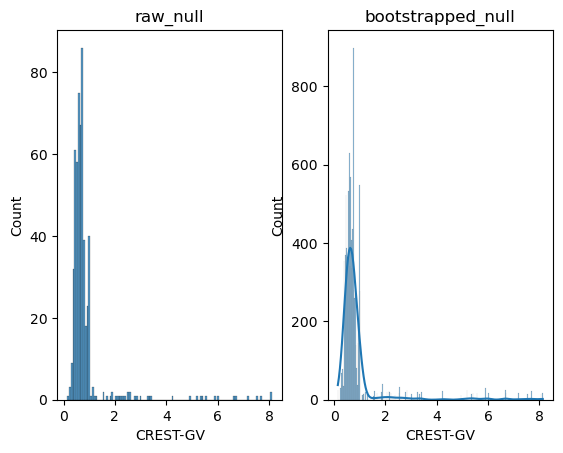

In [80]:
random_collection = "catlas_adult"
output = "pvalues_test/Bcell_GO_0035456_" + random_collection + "/"

df_cgv_with_pvals = generate_pvalue(genetic = genetic, output = output, real_df_cgv = df_cgv,
                                    random_collection = random_collection, random_collection_path="")

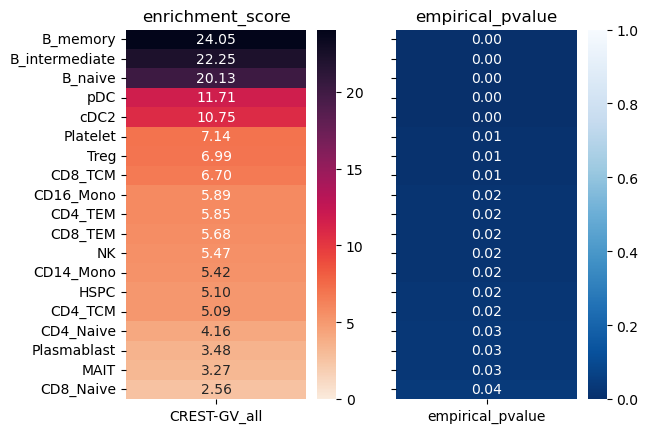

In [81]:
plot_pvalue(df_cgv_pvals)

## Randomly selected list of N celltypes

In [24]:
## Now try on a set of 25 cell types chosen at random from the whole list
our_df = pd.read_csv('/project/Wellcome_Discovery/svenkat/CREST-GV/data/our_data_collection.txt', sep='\t')

In [25]:
# Sample rows at random without replacement from this dataframe
our_df_50 = our_df.sample(50, replace=False, random_state=42)

# Write to a temp file that will be deleted
our_df_50.to_csv('/project/Wellcome_Discovery/svenkat/CREST-GV/data/tmp.txt', index=False, header=False)

# In the next cell: create symbolic links to the data files

In [31]:
%%bash

cd /project/Wellcome_Discovery/svenkat/CREST-GV/data/

rm -r random_50
mkdir random_50
mkdir random_50/peaks
mkdir random_50/bigwigs

# Write info file
touch random_50/random_50_info.csv

while IFS=',' read -r collection celltype info; do

    for bed_file in "/project/Wellcome_Discovery/datashare/CREST-GV_collection/${collection}/peaks/${celltype}"*.bed; do
        ln -s "$bed_file" "/project/Wellcome_Discovery/svenkat/CREST-GV/data/random_50/peaks/${collection}_${celltype}.bed"
    done
    
    for bw_file in "/project/Wellcome_Discovery/datashare/CREST-GV_collection/${collection}/bigwigs/${celltype}"*.bw; do
        ln -s "$bw_file" "/project/Wellcome_Discovery/svenkat/CREST-GV/data/random_50/bigwigs/${collection}_${celltype}.bw"
    done
    
    echo "${collection}_${celltype}" >> random_50/random_50_info.csv
    
done < tmp.txt

In [27]:
# Get the real enrichment data
crestgv_fname = sorted(glob.glob("pvalues_test/Bcell_GO_0035456/statistics_CREST-GV.csv"))
df_cgv = pd.read_csv(crestgv_fname[0], sep='\t', index_col=0)

Removing NaN rows from loaded file ...
Total number of used variants in CREST-GV: 527
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|██████████| 25/25 [00:00<00:00, 100.29it/s]


Intersecting genetic with peak regions ...


100%|██████████| 25/25 [00:03<00:00,  7.97it/s]


For each fold, parallelised shuffling background ...
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


...

Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:18<00:00,  3.75s/it]


Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:16<00:00,  3.40s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.


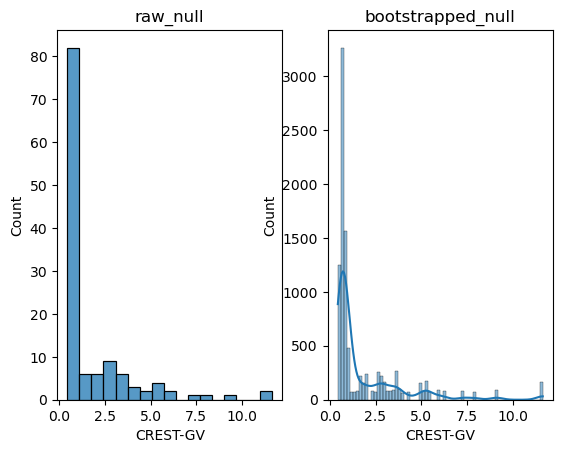

In [32]:
# Get the null p-values
genetic  = "genetics_test/Bcell_GO_0035456.tsv"
random_collection_path = "/project/Wellcome_Discovery/svenkat/CREST-GV/data/random_50"
output = "pvalues_test/Bcell_GO_0035456_random_50/"

df_cgv_with_pvals = generate_pvalue(genetic = genetic, output = output, real_df_cgv = df_cgv,
                                    random_collection = "", random_collection_path = random_collection_path)

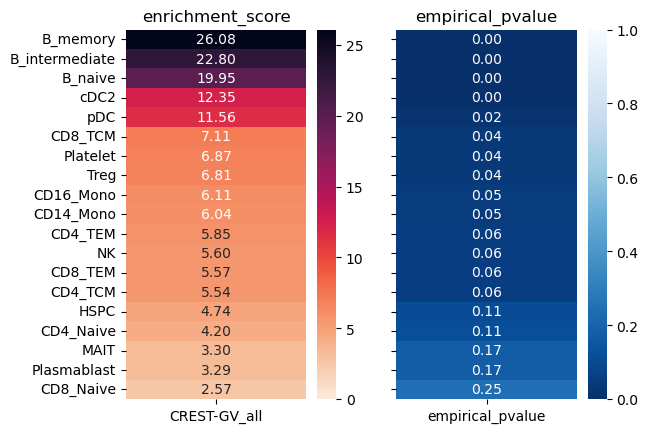

In [33]:
plot_pvalue(df_cgv_with_pvals)

## Sample X% of each collection so we get a representative sample

In [41]:
our_df_perc5 = our_df.groupby('collection_folder_name').apply(lambda x: x.sample(frac=0.05, random_state=42))
# Write to a temp file that will be deleted
our_df_perc5.to_csv('/project/Wellcome_Discovery/svenkat/CREST-GV/data/tmp.txt', index=False, header=False)

# In the next cell: create symbolic links to the data files

In [42]:
%%bash

cd /project/Wellcome_Discovery/svenkat/CREST-GV/data/

rm -r perc_5
mkdir perc_5
mkdir perc_5/peaks
mkdir perc_5/bigwigs

# Write info file
touch perc_5/perc_5_info.csv

while IFS=',' read -r collection celltype info; do

    for bed_file in "/project/Wellcome_Discovery/datashare/CREST-GV_collection/${collection}/peaks/${celltype}"*.bed; do
        ln -s "$bed_file" "/project/Wellcome_Discovery/svenkat/CREST-GV/data/perc_5/peaks/${collection}_${celltype}.bed"
    done
    
    for bw_file in "/project/Wellcome_Discovery/datashare/CREST-GV_collection/${collection}/bigwigs/${celltype}"*.bw; do
        ln -s "$bw_file" "/project/Wellcome_Discovery/svenkat/CREST-GV/data/perc_5/bigwigs/${collection}_${celltype}.bw"
    done
    
    echo "${collection}_${celltype}" >> perc_5/perc_5_info.csv
    
done < tmp.txt

rm: cannot remove 'perc_5': No such file or directory


Removing NaN rows from loaded file ...
Total number of used variants in CREST-GV: 527
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|██████████| 26/26 [00:00<00:00, 126.47it/s]


Intersecting genetic with peak regions ...


100%|██████████| 26/26 [00:02<00:00, 10.42it/s]


For each fold, parallelised shuffling background ...
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


...

Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:13<00:00,  2.77s/it]


Calculating statistics ...
Adding shuffled background ...


100%|██████████| 5/5 [00:13<00:00,  2.77s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.


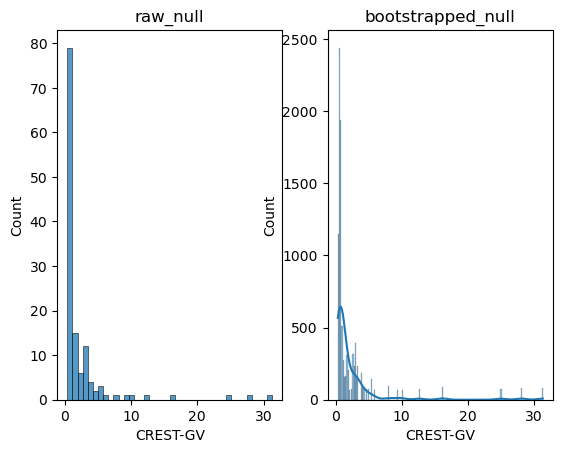

In [43]:
# Get the null p-values
genetic  = "genetics_test/Bcell_GO_0035456.tsv"
random_collection_path = "/project/Wellcome_Discovery/svenkat/CREST-GV/data/perc_5"
output = "pvalues_test/Bcell_GO_0035456_perc_5/"

df_cgv_with_pvals = generate_pvalue(genetic = genetic, output = output, real_df_cgv = df_cgv,
                                    random_collection = "", random_collection_path = random_collection_path)

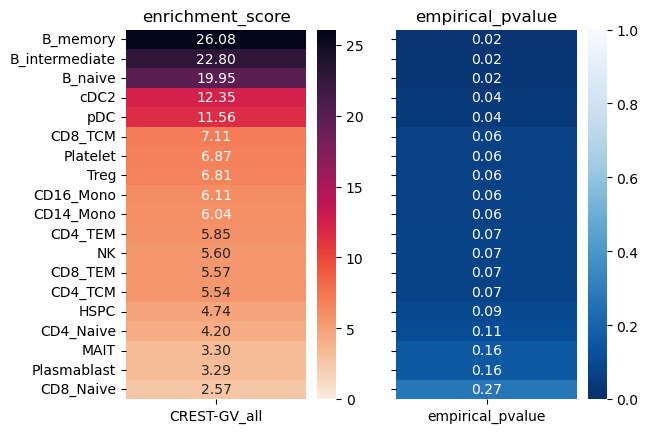

In [44]:
plot_pvalue(df_cgv_with_pvals)